# Лекция 14. Игровая теория состязательного обучения и системная безопасность

Демонстрация: итеративная игра 'атакующий vs защитник' (несколько раундов PGD-атаки и adversarial retraining), упрощённая модель min-max равновесия.

## 1. Итеративная игра атака-защита (multi-round arms race)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=1, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc = nn.Linear(32*7*7,10)
    def forward(self,x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x,2)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = SimpleCNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for i,(xb,yb) in enumerate(train_loader):
    opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
    if i>=300: break
print("Базовая модель обучена, loss:", loss.item())

def pgd_attack(model, x, y, eps=0.15, alpha=0.02, iters=10):
    x_orig = x.clone().detach()
    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)
    x_adv = torch.clamp(x_adv, 0, 1).detach()
    for _ in range(iters):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha*grad.sign()
        x_adv = torch.max(torch.min(x_adv, x_orig+eps), x_orig-eps)
        x_adv = torch.clamp(x_adv, 0, 1)
    return x_adv.detach()

def eval_robust_acc(m, loader, eps, n=150):
    correct, total = 0, 0
    for i,(x,y) in enumerate(loader):
        if i>=n: break
        x_adv = pgd_attack(m, x, y, eps=eps)
        correct += (m(x_adv).argmax(1)==y).sum().item(); total += len(y)
    return correct/total

game_model = SimpleCNN()
opt_g = torch.optim.Adam(game_model.parameters(), lr=1e-3)
rounds = 4
robust_acc_history = []

for r in range(rounds):
    for i,(xb,yb) in enumerate(train_loader):
        if i>=150: break
        x_adv = pgd_attack(game_model, xb, yb, eps=0.1+0.03*r)
        opt_g.zero_grad(); loss = F.cross_entropy(game_model(x_adv), yb); loss.backward(); opt_g.step()
    acc = eval_robust_acc(game_model, test_loader, eps=0.1+0.03*r)
    robust_acc_history.append(acc)
    print(f"Раунд {r+1}: атакующий усиливает eps={0.1+0.03*r:.2f}, защитник дообучается, robust acc={acc:.2%}")


Базовая модель обучена, loss: 0.11312925815582275
Раунд 1: атакующий усиливает eps=0.10, защитник дообучается, robust acc=74.00%
Раунд 2: атакующий усиливает eps=0.13, защитник дообучается, robust acc=77.33%
Раунд 3: атакующий усиливает eps=0.16, защитник дообучается, robust acc=88.00%
Раунд 4: атакующий усиливает eps=0.19, защитник дообучается, robust acc=80.67%


## 2. Визуализация динамики 'гонки' атакующий-защитник

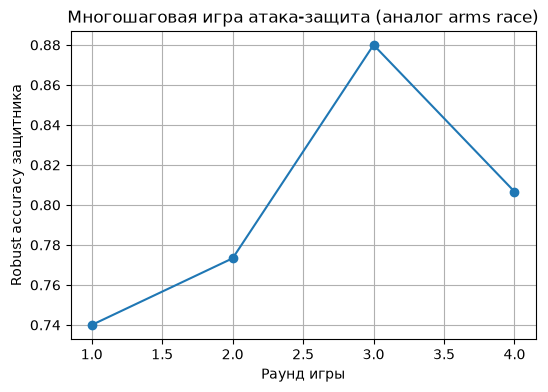

In [2]:

plt.figure(figsize=(6,4))
plt.plot(range(1,rounds+1), robust_acc_history, marker='o')
plt.xlabel("Раунд игры"); plt.ylabel("Robust accuracy защитника")
plt.title("Многошаговая игра атака-защита (аналог arms race)")
plt.grid(True)
plt.savefig('output/notebooks/lec14_game.png', dpi=120)
plt.show()


## 3. Упрощённая иллюстрация min-max равновесия (игрушечная матричная игра)

In [3]:

# Матрица выигрышей защитника: строки - стратегии защиты, столбцы - стратегии атаки
payoff = np.array([
    [0.9, 0.4, 0.2],
    [0.6, 0.7, 0.5],
    [0.3, 0.5, 0.8],
])
defense_strategies = ["Без защиты", "Adversarial training (слабый)", "Adversarial training (сильный)"]
attack_strategies = ["Нет атаки", "FGSM", "PGD"]

best_defense_per_attack = payoff.argmax(axis=0)
worst_case_defense = payoff.min(axis=1).argmax()  # max-min стратегия защитника

print("Матрица 'выигрыша защитника' (accuracy) по парам (защита x атака):")
print(payoff)
print("\nMax-min стратегия защитника (гарантирует лучший результат в худшем случае):",
      defense_strategies[worst_case_defense])


Матрица 'выигрыша защитника' (accuracy) по парам (защита x атака):
[[0.9 0.4 0.2]
 [0.6 0.7 0.5]
 [0.3 0.5 0.8]]

Max-min стратегия защитника (гарантирует лучший результат в худшем случае): Adversarial training (слабый)
